In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# Kiểm tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
!nvidia-smi

# Tạo thư mục
os.makedirs('/kaggle/working/data', exist_ok=True)
os.makedirs('/kaggle/working/models', exist_ok=True)
os.makedirs('/kaggle/working/output', exist_ok=True)
print("✅ Setup xong!")

Device: cuda
Sat May 23 17:58:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------------

In [2]:
import ast

META_PATH = '/kaggle/input/datasets/sooduyanh/fasshion-dataset/Data/images/meta_clothing.json/meta_Clothing_Shoes_and_Jewelry.json'

print('Đọc metadata (chỉ lấy fields cần thiết)...')
records = []
NEEDED = {'asin', 'title', 'categories', 'related', 'imUrl'}

with open(META_PATH, 'r', encoding='utf-8') as f:
    for line in tqdm(f):
        line = line.strip()
        if not line:
            continue
        try:
            rec = json.loads(line)
        except:
            try:
                rec = ast.literal_eval(line)
            except:
                continue
        records.append({k: rec.get(k) for k in NEEDED})

meta_df = pd.DataFrame(records)
print(f'✅ Đọc xong: {len(meta_df):,} sản phẩm')
print(meta_df.columns.tolist())

Đọc metadata (chỉ lấy fields cần thiết)...


1503384it [03:58, 6294.37it/s]


✅ Đọc xong: 1,503,384 sản phẩm
['title', 'related', 'categories', 'asin', 'imUrl']


In [3]:
# Phân loại sản phẩm
def classify_category(categories):
    if not isinstance(categories, list) or len(categories) == 0:
        return 'Other'
    flat = [item.lower().strip() for sublist in categories for item in sublist]
    text = ' '.join(flat)
    if any(w in text for w in ['shirt','blouse','top','t-shirt','sweater',
                                'hoodie','jacket','coat','cardigan','tank',
                                'camisole','dress','blazer']):
        return 'Tops'
    elif any(w in text for w in ['pants','trousers','jeans','shorts','leggings',
                                  'skirt','bottom','capri','joggers']):
        return 'Bottoms'
    elif any(w in text for w in ['shoes','boots','sandals','sneakers','heels',
                                  'loafers','flats','slippers','oxfords','pumps']):
        return 'Shoes'
    return 'Other'

meta_df['main_cat'] = meta_df['categories'].apply(classify_category)
items = meta_df[meta_df['main_cat'].isin(['Tops','Bottoms','Shoes'])].copy()
asin_to_cat = items.set_index('asin')['main_cat'].to_dict()
asin_to_title = items.set_index('asin')['title'].fillna('').to_dict()

print('Phân loại:')
print(items['main_cat'].value_counts())
print(f'\nTổng sản phẩm hợp lệ: {len(items):,}')

Phân loại:
main_cat
Shoes      1095976
Tops        324900
Bottoms      82508
Name: count, dtype: int64

Tổng sản phẩm hợp lệ: 1,503,384


In [4]:
# Load triplets gốc
TRIPLET_PATH = '/kaggle/input/datasets/sooduyanh/fasshion-dataset/Data/images/triplets.csv'
triplet_df = pd.read_csv(TRIPLET_PATH)
print(f'Triplets gốc: {len(triplet_df):,}')
print(triplet_df.head())

Triplets gốc: 2,668
          top      bottom        shoe
0  B00193QM86  B008AHISU4  B001FOR2DS
1  B0058YVS4U  B005ACU6L6  B006H30KX6
2  B0058YVS4U  B003AU5W5K  B007K5VWLY
3  B0058YVS4U  B00AKSBSQW  B004BKIPXO
4  B001NU5362  B001QD84JY  B0043VDHYS


In [5]:
# ── Tăng triplets từ also_bought ──────────────────────────────────────────────
# Xây index: asin → set(also_bought) đã được phân loại
print('Xây also_bought index...')

also_bought_map = {}  # asin -> list[asin] cùng loại hoặc phân loại khác
for _, row in tqdm(meta_df.iterrows(), total=len(meta_df)):
    asin = row['asin']
    related = row.get('related')
    if not isinstance(related, dict):
        continue
    ab = related.get('also_bought', [])
    if isinstance(ab, list) and len(ab) > 0:
        also_bought_map[asin] = ab

print(f'Items có also_bought: {len(also_bought_map):,}')

# Lấy set asins theo category
top_set  = set(items[items['main_cat']=='Tops']['asin'])
bot_set  = set(items[items['main_cat']=='Bottoms']['asin'])
shoe_set = set(items[items['main_cat']=='Shoes']['asin'])

# Sinh triplets mới: top → also_bought shoes → also_bought bottoms
# Logic: nếu top A also_bought với shoe C, và bottom B also_bought với shoe C → (A,B,C) là bộ

print('Sinh triplets từ also_bought...')
np.random.seed(42)

shoe_to_tops  = {}  # shoe -> tops that also_bought it
shoe_to_bots  = {}  # shoe -> bottoms that also_bought it

for asin, ab_list in also_bought_map.items():
    cat = asin_to_cat.get(asin)
    for target in ab_list:
        if target in shoe_set:
            if cat == 'Tops':
                shoe_to_tops.setdefault(target, []).append(asin)
            elif cat == 'Bottoms':
                shoe_to_bots.setdefault(target, []).append(asin)
        elif target in top_set and cat == 'Shoes':
            shoe_to_tops.setdefault(asin, []).append(target)
        elif target in bot_set and cat == 'Shoes':
            shoe_to_bots.setdefault(asin, []).append(target)

new_triplets = []
for shoe in shoe_set:
    tops = shoe_to_tops.get(shoe, [])
    bots = shoe_to_bots.get(shoe, [])
    if len(tops) == 0 or len(bots) == 0:
        continue
    # Lấy tối đa 5 cặp (top, bot) cho mỗi shoe để tránh dominance
    sampled_tops = tops[:5]
    sampled_bots = bots[:5]
    for t in sampled_tops:
        for b in sampled_bots:
            new_triplets.append({'top': t, 'bottom': b, 'shoe': shoe})

new_df = pd.DataFrame(new_triplets).drop_duplicates()
print(f'Triplets mới từ also_bought: {len(new_df):,}')

# Gộp và deduplicate
combined = pd.concat([triplet_df, new_df], ignore_index=True).drop_duplicates()
print(f'Tổng triplets sau gộp: {len(combined):,}')

Xây also_bought index...


100%|██████████| 1503384/1503384 [00:55<00:00, 27148.76it/s]


Items có also_bought: 661,883
Sinh triplets từ also_bought...
Triplets mới từ also_bought: 321,759
Tổng triplets sau gộp: 324,418


In [7]:
# Load VGG features
from sklearn.preprocessing import normalize   # ← thêm dòng này

FEAT_PATH = '/kaggle/input/datasets/sooduyanh/fasshion-dataset/Data/image_features.npy'
features_dict_raw = np.load(FEAT_PATH, allow_pickle=True).item()
print(f'✅ VGG features: {len(features_dict_raw):,} sản phẩm')
FEAT_DIM = next(iter(features_dict_raw.values())).shape[0]
print(f'Feature dim: {FEAT_DIM}')

# Normalize VGG features (L2 norm) trước DAE
print('Normalize VGG features (L2 norm)...')
all_vgg_asins = list(features_dict_raw.keys())
vgg_matrix = np.stack([features_dict_raw[a].astype(np.float32) for a in all_vgg_asins])
vgg_matrix_norm = normalize(vgg_matrix, norm='l2')  # (N, 4096)
features_dict = {a: vgg_matrix_norm[i] for i, a in enumerate(all_vgg_asins)}
print('✅ VGG features đã normalize!')

✅ VGG features: 2,202 sản phẩm
Feature dim: 4096
Normalize VGG features (L2 norm)...
✅ VGG features đã normalize!


In [8]:
# Train/Test split 90/10
np.random.seed(42)
triplet_df = triplet_df.sample(frac=1).reset_index(drop=True)
split = int(0.9 * len(triplet_df))

train_df = triplet_df.iloc[:split].reset_index(drop=True)
test_df  = triplet_df.iloc[split:].reset_index(drop=True)
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')

# Index mapping cho tất cả items
all_asins = sorted(list(features_dict.keys()))
asin_to_idx = {asin: idx for idx, asin in enumerate(all_asins)}
num_items = len(all_asins)
print(f'Số items: {num_items:,}')

Train: 2,401  |  Test: 267
Số items: 2,202


In [9]:
class ELFMImproved(nn.Module):
    """
    Extended LFM cải tiến:
    - Bias per item
    - Dropout 0.1
    - Công thức: r = p1.p2 + p2.p3 + p1.p3 + b1 + b2 + b3
    """
    def __init__(self, num_items, latent_dim=100):
        super().__init__()
        self.embeddings = nn.Embedding(num_items, latent_dim)
        self.bias = nn.Embedding(num_items, 1)  # bias per item
        self.dropout = nn.Dropout(0.1)
        nn.init.uniform_(self.embeddings.weight, 0, 1)
        nn.init.zeros_(self.bias.weight)

    def forward(self, i1, i2, i3):
        p1 = self.dropout(self.embeddings(i1))
        p2 = self.dropout(self.embeddings(i2))
        p3 = self.dropout(self.embeddings(i3))
        b1 = self.bias(i1).squeeze(-1)
        b2 = self.bias(i2).squeeze(-1)
        b3 = self.bias(i3).squeeze(-1)
        r = ((p1*p2).sum(1) + (p2*p3).sum(1) + (p1*p3).sum(1)
             + b1 + b2 + b3)
        return r


class TripletDataset(Dataset):
    """Dataset cho E-LFM với negative sampling."""
    def __init__(self, df, asin_to_idx, num_items, neg_ratio=4):
        self.positives = []
        for _, row in df.iterrows():
            if (row['top'] in asin_to_idx and
                row['bottom'] in asin_to_idx and
                row['shoe'] in asin_to_idx):
                self.positives.append((
                    asin_to_idx[row['top']],
                    asin_to_idx[row['bottom']],
                    asin_to_idx[row['shoe']]
                ))
        self.num_items = num_items
        self.neg_ratio = neg_ratio

    def __len__(self):
        return len(self.positives) * (1 + self.neg_ratio)

    def __getitem__(self, idx):
        pos_idx = idx // (1 + self.neg_ratio)
        is_neg  = (idx % (1 + self.neg_ratio)) != 0
        i1, i2, i3 = self.positives[pos_idx]

        if is_neg:
            slot = np.random.randint(3)
            rand = np.random.randint(self.num_items)
            if slot == 0: i1 = rand
            elif slot == 1: i2 = rand
            else: i3 = rand
            label = 0.0
        else:
            label = 1.0

        return (
            torch.tensor(i1, dtype=torch.long),
            torch.tensor(i2, dtype=torch.long),
            torch.tensor(i3, dtype=torch.long),
            torch.tensor(label, dtype=torch.float)
        )

print('✅ Định nghĩa ELFMImproved & TripletDataset xong!')

✅ Định nghĩa ELFMImproved & TripletDataset xong!


In [10]:
# Train ELFMImproved (dùng chung cho Paper Hybrid và CLIP Hybrid)
elfm_imp = ELFMImproved(num_items, latent_dim=100).to(device)
optimizer_imp = optim.Adam(elfm_imp.parameters(), lr=0.001, weight_decay=1e-5)
criterion_imp = nn.BCEWithLogitsLoss()

train_dataset_imp = TripletDataset(train_df, asin_to_idx, num_items, neg_ratio=4)
train_loader_imp  = DataLoader(train_dataset_imp, batch_size=512, shuffle=True, num_workers=2)

EPOCHS_LFM = 30
print(f'Train ELFMImproved | {len(train_dataset_imp):,} samples | {EPOCHS_LFM} epochs')
print('-' * 55)

for epoch in range(EPOCHS_LFM):
    elfm_imp.train()
    total_loss = 0
    for i1, i2, i3, label in train_loader_imp:
        i1, i2, i3, label = i1.to(device), i2.to(device), i3.to(device), label.to(device)
        score = elfm_imp(i1, i2, i3)
        loss = criterion_imp(score, label)
        optimizer_imp.zero_grad()
        loss.backward()
        optimizer_imp.step()
        total_loss += loss.item()
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{EPOCHS_LFM} | Loss: {total_loss/len(train_loader_imp):.4f}')

torch.save(elfm_imp.state_dict(), '/kaggle/working/models/elfm_improved.pth')
print('\n✅ ELFMImproved trained & saved!')

# Precompute embeddings (dùng chung cho tất cả methods)
elfm_imp.eval()
with torch.no_grad():
    all_idx = torch.arange(num_items).to(device)
    lfm_embeddings = elfm_imp.embeddings(all_idx).cpu().numpy()  # (N, 100)
print(f'LFM embeddings precomputed: {lfm_embeddings.shape}')

Train ELFMImproved | 9,940 samples | 30 epochs
-------------------------------------------------------
Epoch  1/30 | Loss: 58.3586
Epoch  5/30 | Loss: 47.7721
Epoch 10/30 | Loss: 36.7752
Epoch 15/30 | Loss: 27.8839
Epoch 20/30 | Loss: 20.6539
Epoch 25/30 | Loss: 14.9401
Epoch 30/30 | Loss: 10.3968

✅ ELFMImproved trained & saved!
LFM embeddings precomputed: (2202, 100)


In [11]:
INPUT_DIM = FEAT_DIM * 3  # 4096 × 3 = 12288

class FashionDAEDataset(Dataset):
    """
    Input  : [f_top_norm | f_bottom_norm | zeros]  (12288)
    Target : [f_top_norm | f_bottom_norm | f_shoe_norm]  (12288)
    """
    def __init__(self, df, features_dict, feat_dim):
        self.samples = []
        for _, row in df.iterrows():
            top, bot, shoe = row['top'], row['bottom'], row['shoe']
            if top in features_dict and bot in features_dict and shoe in features_dict:
                f_top  = features_dict[top].astype(np.float32)
                f_bot  = features_dict[bot].astype(np.float32)
                f_shoe = features_dict[shoe].astype(np.float32)
                full   = np.concatenate([f_top, f_bot, f_shoe])
                masked = np.concatenate([f_top, f_bot, np.zeros(feat_dim, dtype=np.float32)])
                self.samples.append((masked, full))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        m, f = self.samples[idx]
        return torch.FloatTensor(m), torch.FloatTensor(f)


class FashionDAE(nn.Module):
    """DAE Conv1D theo bài báo: encoder 128-64-64 / decoder 64-64-128-1."""
    def __init__(self, input_dim=12288):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(128, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),  nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, padding=1),  nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(128, 1, kernel_size=3, padding=1),
        )

    def forward(self, x):
        x = x.unsqueeze(1)      # (B, 1, D)
        latent = self.encoder(x)
        out = self.decoder(latent).squeeze(1)  # (B, D)
        return out, latent

    def get_shoe_feature(self, x, feat_dim):
        out, _ = self.forward(x)
        return out[:, -feat_dim:]


dae_train = FashionDAEDataset(train_df, features_dict, FEAT_DIM)
dae_loader = DataLoader(dae_train, batch_size=256, shuffle=True, num_workers=2)

# ── THAY ĐỔI 1b: dùng MSELoss thay BCELoss ───────────────────────────────────
dae = FashionDAE(INPUT_DIM).to(device)
optimizer_dae = optim.Adam(dae.parameters(), lr=0.001)
criterion_dae = nn.MSELoss()  # MSELoss vì features đã normalize (không cần sigmoid)

EPOCHS_DAE = 40
print(f'Train FashionDAE (VGG, MSELoss) | {len(dae_train):,} samples | {EPOCHS_DAE} epochs')
print('-' * 55)

for epoch in range(EPOCHS_DAE):
    dae.train()
    total_loss = 0
    for masked, full in dae_loader:
        masked, full = masked.to(device), full.to(device)
        reconstructed, _ = dae(masked)
        loss = criterion_dae(reconstructed, full)
        optimizer_dae.zero_grad()
        loss.backward()
        optimizer_dae.step()
        total_loss += loss.item()
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{EPOCHS_DAE} | Loss: {total_loss/len(dae_loader):.6f}')

torch.save(dae.state_dict(), '/kaggle/working/models/dae_vgg_mse.pth')
print('\n✅ FashionDAE (VGG, MSELoss) trained & saved!')

Train FashionDAE (VGG, MSELoss) | 1,988 samples | 40 epochs
-------------------------------------------------------
Epoch  1/40 | Loss: 0.000391
Epoch 10/40 | Loss: 0.000102
Epoch 20/40 | Loss: 0.000077
Epoch 30/40 | Loss: 0.000077
Epoch 40/40 | Loss: 0.000076

✅ FashionDAE (VGG, MSELoss) trained & saved!


In [12]:
!pip install -q open_clip_torch

import open_clip
import requests
from PIL import Image
from io import BytesIO

clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='laion2b_s34b_b79k'
)
clip_model = clip_model.to(device).eval()

CLIP_PATH = '/kaggle/input/datasets/sooduyanh/fasshion-dataset/Data/clip_embeddings.npy'

if os.path.exists(CLIP_PATH):
    clip_embeddings = np.load(CLIP_PATH, allow_pickle=True).item()
    print(f'✅ Loaded CLIP embeddings: {len(clip_embeddings):,}')
else:
    asin_to_url = items[items['asin'].isin(all_asins)].set_index('asin')['imUrl'].to_dict()
    clip_embeddings = {}
    for asin, url in tqdm(asin_to_url.items(), desc='CLIP'):
        try:
            resp = requests.get(url, timeout=10)
            img = Image.open(BytesIO(resp.content)).convert('RGB')
            img_t = preprocess(img).unsqueeze(0).to(device)
            with torch.no_grad():
                emb = clip_model.encode_image(img_t)
                emb = emb / emb.norm(dim=-1, keepdim=True)
            clip_embeddings[asin] = emb.cpu().numpy().squeeze()
        except:
            continue
    print(f'✅ Extracted CLIP: {len(clip_embeddings):,}')

CLIP_DIM = 512

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

✅ Loaded CLIP embeddings: 2,202


In [13]:
class CLIPDenoisingDataset(Dataset):
    def __init__(self, df, clip_embs, clip_dim=512):
        self.samples = []
        self.clip_dim = clip_dim
        for _, row in df.iterrows():
            t, b, s = row['top'], row['bottom'], row['shoe']
            if t in clip_embs and b in clip_embs and s in clip_embs:
                ft = clip_embs[t].astype(np.float32)
                fb = clip_embs[b].astype(np.float32)
                fs = clip_embs[s].astype(np.float32)
                full   = np.concatenate([ft, fb, fs])
                masked = np.concatenate([ft, fb, np.zeros(clip_dim, np.float32)])
                self.samples.append((masked, full))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        m, f = self.samples[idx]
        return torch.FloatTensor(m), torch.FloatTensor(f)


class TypeAwareDAE(nn.Module):
    """CLIP-DAE: MLP Encoder-Decoder, input 1536 chiều."""
    def __init__(self, clip_dim=512):
        super().__init__()
        input_dim = clip_dim * 3
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(1024, 512),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 256),        nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 1024),       nn.ReLU(),
            nn.Linear(1024, input_dim),
        )

    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent), latent

    def predict_shoe(self, top_emb, bot_emb, clip_dim=512):
        masked = torch.cat([
            top_emb, bot_emb,
            torch.zeros(top_emb.shape[0], clip_dim).to(top_emb.device)
        ], dim=1)
        out, _ = self.forward(masked)
        return out[:, -clip_dim:]


clip_train  = CLIPDenoisingDataset(train_df, clip_embeddings, CLIP_DIM)
clip_loader = DataLoader(clip_train, batch_size=256, shuffle=True, num_workers=2)

model_clip_dae = TypeAwareDAE(CLIP_DIM).to(device)
opt_clip  = optim.Adam(model_clip_dae.parameters(), lr=0.001)
crit_clip = nn.MSELoss()

EPOCHS_CLIP = 50
print(f'Train CLIP-DAE | {len(clip_train):,} samples | {EPOCHS_CLIP} epochs')

for epoch in range(EPOCHS_CLIP):
    model_clip_dae.train()
    total = 0
    for m, f in clip_loader:
        m, f = m.to(device), f.to(device)
        out, _ = model_clip_dae(m)
        loss = crit_clip(out, f)
        opt_clip.zero_grad()
        loss.backward()
        opt_clip.step()
        total += loss.item()
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{EPOCHS_CLIP} | Loss: {total/len(clip_loader):.6f}')

torch.save(model_clip_dae.state_dict(), '/kaggle/working/models/clip_dae.pth')
print('✅ CLIP-DAE trained & saved!')

Train CLIP-DAE | 1,988 samples | 50 epochs
Epoch  1/50 | Loss: 0.001541
Epoch 10/50 | Loss: 0.000937
Epoch 20/50 | Loss: 0.000787
Epoch 30/50 | Loss: 0.000654
Epoch 40/50 | Loss: 0.000560
Epoch 50/50 | Loss: 0.000485
✅ CLIP-DAE trained & saved!


In [14]:
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer

TEXT_EMB_PATH = '/kaggle/working/data/text_embeddings.npy'

if os.path.exists(TEXT_EMB_PATH):
    text_embeddings = np.load(TEXT_EMB_PATH, allow_pickle=True).item()
    print(f'✅ Loaded text embeddings: {len(text_embeddings):,}')
else:
    print('Trích xuất text embeddings từ title...')
    st_model = SentenceTransformer('all-MiniLM-L6-v2', device=str(device))

    # Chỉ lấy asins trong all_asins (có VGG features)
    target_asins = all_asins
    titles = [str(asin_to_title.get(a, a)) for a in target_asins]

    BATCH = 512
    text_embeddings = {}
    for i in tqdm(range(0, len(target_asins), BATCH), desc='Text emb'):
        batch_asins = target_asins[i:i+BATCH]
        batch_titles = titles[i:i+BATCH]
        embs = st_model.encode(batch_titles, batch_size=BATCH,
                               show_progress_bar=False, normalize_embeddings=True)
        for asin, emb in zip(batch_asins, embs):
            text_embeddings[asin] = emb.astype(np.float32)

    np.save(TEXT_EMB_PATH, text_embeddings)
    print(f'✅ Text embeddings extracted & saved: {len(text_embeddings):,}')

TEXT_DIM = next(iter(text_embeddings.values())).shape[0]
print(f'Text embedding dim: {TEXT_DIM}')

Trích xuất text embeddings từ title...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Text emb: 100%|██████████| 5/5 [00:01<00:00,  4.41it/s]

✅ Text embeddings extracted & saved: 2,202
Text embedding dim: 384


In [15]:
# Text-DAE: cùng kiến trúc như CLIP-DAE nhưng dùng text embeddings

class TextDenoisingDataset(Dataset):
    def __init__(self, df, text_embs, text_dim):
        self.samples = []
        self.text_dim = text_dim
        for _, row in df.iterrows():
            t, b, s = row['top'], row['bottom'], row['shoe']
            if t in text_embs and b in text_embs and s in text_embs:
                ft = text_embs[t].astype(np.float32)
                fb = text_embs[b].astype(np.float32)
                fs = text_embs[s].astype(np.float32)
                full   = np.concatenate([ft, fb, fs])
                masked = np.concatenate([ft, fb, np.zeros(text_dim, np.float32)])
                self.samples.append((masked, full))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        m, f = self.samples[idx]
        return torch.FloatTensor(m), torch.FloatTensor(f)


class TextDAE(nn.Module):
    """Text-DAE: MLP Encoder-Decoder, input = text_dim*3."""
    def __init__(self, text_dim=384):
        super().__init__()
        input_dim = text_dim * 3
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128),       nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 256),       nn.ReLU(),
            nn.Linear(256, 512),       nn.ReLU(),
            nn.Linear(512, input_dim),
        )

    def forward(self, x):
        latent = self.encoder(x)
        return self.decoder(latent), latent

    def predict_shoe(self, top_emb, bot_emb, text_dim):
        masked = torch.cat([
            top_emb, bot_emb,
            torch.zeros(top_emb.shape[0], text_dim).to(top_emb.device)
        ], dim=1)
        out, _ = self.forward(masked)
        return out[:, -text_dim:]


text_train  = TextDenoisingDataset(train_df, text_embeddings, TEXT_DIM)
text_loader = DataLoader(text_train, batch_size=256, shuffle=True, num_workers=2)

model_text_dae = TextDAE(TEXT_DIM).to(device)
opt_text  = optim.Adam(model_text_dae.parameters(), lr=0.001)
crit_text = nn.MSELoss()

EPOCHS_TEXT = 40
print(f'Train Text-DAE | {len(text_train):,} samples | {EPOCHS_TEXT} epochs')

for epoch in range(EPOCHS_TEXT):
    model_text_dae.train()
    total = 0
    for m, f in text_loader:
        m, f = m.to(device), f.to(device)
        out, _ = model_text_dae(m)
        loss = crit_text(out, f)
        opt_text.zero_grad()
        loss.backward()
        opt_text.step()
        total += loss.item()
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{EPOCHS_TEXT} | Loss: {total/len(text_loader):.6f}')

torch.save(model_text_dae.state_dict(), '/kaggle/working/models/text_dae.pth')
print('✅ Text-DAE trained & saved!')

Train Text-DAE | 1,988 samples | 40 epochs
Epoch  1/40 | Loss: 0.002324
Epoch 10/40 | Loss: 0.001578
Epoch 20/40 | Loss: 0.001344
Epoch 30/40 | Loss: 0.001156
Epoch 40/40 | Loss: 0.001022
✅ Text-DAE trained & saved!


In [16]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Candidate shoes
all_shoes = [a for a in all_asins if asin_to_cat.get(a) == 'Shoes']
print(f'Candidate shoes: {len(all_shoes):,}')

# ── Helper: tính rank dict từ score dict (cao → rank 1) ──────────────────────
def scores_to_ranks(score_dict):
    ranked = sorted(score_dict, key=score_dict.get, reverse=True)
    return {s: i+1 for i, s in enumerate(ranked)}

# ── RRF fusion ────────────────────────────────────────────────────────────────
def rrf_fusion(rank_lists, k=60):
    """Reciprocal Rank Fusion: score = Σ 1/(k + r). Trả về {item: rrf_score}."""
    rrf_scores = {}
    for rank_dict in rank_lists:
        for item, r in rank_dict.items():
            rrf_scores[item] = rrf_scores.get(item, 0.0) + 1.0 / (k + r)
    return rrf_scores

# ── LFM rank ─────────────────────────────────────────────────────────────────
def get_lfm_rank(top_asin, bot_asin, candidates):
    if top_asin not in asin_to_idx or bot_asin not in asin_to_idx:
        return None
    p_top = lfm_embeddings[asin_to_idx[top_asin]]
    p_bot = lfm_embeddings[asin_to_idx[bot_asin]]
    scores = {}
    for shoe in candidates:
        if shoe not in asin_to_idx: continue
        p_s = lfm_embeddings[asin_to_idx[shoe]]
        scores[shoe] = float((p_top@p_bot) + (p_bot@p_s) + (p_top@p_s))
    return scores_to_ranks(scores)

# ── VGG-DAE rank ─────────────────────────────────────────────────────────────
def get_vgg_dae_rank(top_asin, bot_asin, candidates):
    if top_asin not in features_dict or bot_asin not in features_dict:
        return None
    f_top = features_dict[top_asin]
    f_bot = features_dict[bot_asin]
    masked = np.concatenate([f_top, f_bot, np.zeros(FEAT_DIM, np.float32)])
    masked_t = torch.FloatTensor(masked).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_shoe = dae.get_shoe_feature(masked_t, FEAT_DIM).cpu().numpy()
    scores = {}
    for shoe in candidates:
        if shoe not in features_dict: continue
        fs = features_dict[shoe].reshape(1, -1)
        scores[shoe] = float(cos_sim(pred_shoe, fs)[0][0])
    return scores_to_ranks(scores)

# ── CLIP-DAE rank ─────────────────────────────────────────────────────────────
def get_clip_dae_rank(top_asin, bot_asin, candidates):
    if top_asin not in clip_embeddings or bot_asin not in clip_embeddings:
        return None
    ft = torch.FloatTensor(clip_embeddings[top_asin]).unsqueeze(0).to(device)
    fb = torch.FloatTensor(clip_embeddings[bot_asin]).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_shoe = model_clip_dae.predict_shoe(ft, fb, CLIP_DIM).cpu().numpy()
    scores = {}
    for shoe in candidates:
        if shoe not in clip_embeddings: continue
        fs = clip_embeddings[shoe].reshape(1, -1)
        scores[shoe] = float(cos_sim(pred_shoe, fs)[0][0])
    return scores_to_ranks(scores)

# ── Text-DAE rank ─────────────────────────────────────────────────────────────
def get_text_dae_rank(top_asin, bot_asin, candidates):
    if top_asin not in text_embeddings or bot_asin not in text_embeddings:
        return None
    ft = torch.FloatTensor(text_embeddings[top_asin]).unsqueeze(0).to(device)
    fb = torch.FloatTensor(text_embeddings[bot_asin]).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_shoe = model_text_dae.predict_shoe(ft, fb, TEXT_DIM).cpu().numpy()
    scores = {}
    for shoe in candidates:
        if shoe not in text_embeddings: continue
        fs = text_embeddings[shoe].reshape(1, -1)
        scores[shoe] = float(cos_sim(pred_shoe, fs)[0][0])
    return scores_to_ranks(scores)


# ── 4 phương pháp ─────────────────────────────────────────────────────────────

def lfm_only_recommend(top_asin, bot_asin, candidates, k=10):
    rank_lfm = get_lfm_rank(top_asin, bot_asin, candidates)
    if rank_lfm is None: return []
    rrf = rrf_fusion([rank_lfm])
    return sorted(rrf, key=rrf.get, reverse=True)[:k]


def paper_hybrid_recommend(top_asin, bot_asin, candidates, k=10):
    """Paper Hybrid (VGG): ELFMImproved + VGG-DAE, fused bằng RRF."""
    rank_lfm = get_lfm_rank(top_asin, bot_asin, candidates)
    rank_vgg = get_vgg_dae_rank(top_asin, bot_asin, candidates)
    if rank_lfm is None: return []
    lists = [l for l in [rank_lfm, rank_vgg] if l is not None]
    rrf = rrf_fusion(lists)
    return sorted(rrf, key=rrf.get, reverse=True)[:k]


def clip_hybrid_recommend(top_asin, bot_asin, candidates, k=10):
    """CLIP Hybrid: ELFMImproved + CLIP-DAE, fused bằng RRF."""
    rank_lfm  = get_lfm_rank(top_asin, bot_asin, candidates)
    rank_clip = get_clip_dae_rank(top_asin, bot_asin, candidates)
    if rank_lfm is None: return []
    lists = [l for l in [rank_lfm, rank_clip] if l is not None]
    rrf = rrf_fusion(lists)
    return sorted(rrf, key=rrf.get, reverse=True)[:k]


def clip_text_hybrid_recommend(top_asin, bot_asin, candidates, k=10):
    """CLIP+Text Hybrid: ELFMImproved + CLIP-DAE + Text-DAE, fused bằng RRF (3 kênh)."""
    rank_lfm  = get_lfm_rank(top_asin, bot_asin, candidates)
    rank_clip = get_clip_dae_rank(top_asin, bot_asin, candidates)
    rank_text = get_text_dae_rank(top_asin, bot_asin, candidates)
    if rank_lfm is None: return []
    lists = [l for l in [rank_lfm, rank_clip, rank_text] if l is not None]
    rrf = rrf_fusion(lists)
    return sorted(rrf, key=rrf.get, reverse=True)[:k]


print('✅ Recommendation functions ready!')

Candidate shoes: 738
✅ Recommendation functions ready!


In [17]:
def precision_recall_at_k(test_df, recommend_fn, k=10, max_cand=300, sample_n=None):
    """
    Precision@k = hits / |gt|  (gt = 1 → tương đương hit rate)
    Recall@k    = hits / k
    """
    if sample_n is not None:
        eval_df = test_df.sample(min(sample_n, len(test_df)), random_state=42)
    else:
        eval_df = test_df

    prec_sum = recall_sum = 0
    total = len(eval_df)

    for _, row in tqdm(eval_df.iterrows(), total=total, desc=f'Eval k={k}'):
        top, true_bot, true_shoe = row['top'], row['bottom'], row['shoe']

        cand_pool = list(set(
            [true_shoe] +
            list(np.random.choice(all_shoes, min(max_cand-1, len(all_shoes)-1), replace=False))
        ))

        recs = recommend_fn(top, true_bot, cand_pool, k=k)
        hits = 1 if true_shoe in recs else 0

        prec_sum   += hits / 1   # 1 ground truth
        recall_sum += hits / k

    return prec_sum / total, recall_sum / total


print('✅ Evaluation function ready!')

✅ Evaluation function ready!


In [18]:
# Set tất cả models về eval mode
elfm_imp.eval()
dae.eval()
model_clip_dae.eval()
model_text_dae.eval()

SAMPLE_FINAL = 200  # tăng lên nếu muốn ổn định hơn (nhưng chậm hơn)

methods = {
    'LFM only'             : lfm_only_recommend,
    'Paper Hybrid (VGG)'   : paper_hybrid_recommend,
    'CLIP Hybrid (RRF)'    : clip_hybrid_recommend,
    'CLIP+Text Hybrid (RRF)': clip_text_hybrid_recommend,
}

final_results = {}
print('So sánh 4 phương pháp...')
print('=' * 65)

for k in [10, 15, 20]:
    final_results[k] = {}
    print(f'\n--- k = {k} ---')
    for name, fn in methods.items():
        p, r = precision_recall_at_k(
            test_df, fn, k=k, max_cand=300, sample_n=SAMPLE_FINAL
        )
        final_results[k][name] = {'precision': p, 'recall': r}
        print(f'  {name:<30} | P@{k}: {p:.4f} | R@{k}: {r:.4f}')

print('\n✅ Đánh giá xong!')

So sánh 4 phương pháp...

--- k = 10 ---


Eval k=10: 100%|██████████| 200/200 [00:00<00:00, 542.31it/s]


  LFM only                       | P@10: 0.0200 | R@10: 0.0020


Eval k=10: 100%|██████████| 200/200 [00:19<00:00, 10.42it/s]


  Paper Hybrid (VGG)             | P@10: 0.0100 | R@10: 0.0010


...

  Paper Hybrid (VGG)             | P@20: 0.0250 | R@20: 0.0013


Eval k=20: 100%|██████████| 200/200 [00:17<00:00, 11.73it/s]


  CLIP Hybrid (RRF)              | P@20: 0.1700 | R@20: 0.0085


Eval k=20: 100%|██████████| 200/200 [00:33<00:00,  5.96it/s]

  CLIP+Text Hybrid (RRF)         | P@20: 0.5400 | R@20: 0.0270

✅ Đánh giá xong!


In [19]:
# ── In bảng kết quả đẹp ───────────────────────────────────────────────────────
W = 32

print('\n' + '='*70)
print('PRECISION@K')
print('='*70)
print(f"{'Method':<{W}} {'k=10':>10} {'k=15':>10} {'k=20':>10}")
print('-'*70)
for name in methods:
    vals = [final_results[k][name]['precision']*100 for k in [10, 15, 20]]
    print(f"{name:<{W}} {vals[0]:>9.1f}% {vals[1]:>9.1f}% {vals[2]:>9.1f}%")

print('\n' + '='*70)
print('RECALL@K')
print('='*70)
print(f"{'Method':<{W}} {'k=10':>10} {'k=15':>10} {'k=20':>10}")
print('-'*70)
for name in methods:
    vals = [final_results[k][name]['recall']*100 for k in [10, 15, 20]]
    print(f"{name:<{W}} {vals[0]:>9.1f}% {vals[1]:>9.1f}% {vals[2]:>9.1f}%")

# Lưu kết quả ra CSV
rows = []
for name in methods:
    row = {'method': name}
    for k in [10, 15, 20]:
        row[f'P@{k}'] = final_results[k][name]['precision']
        row[f'R@{k}'] = final_results[k][name]['recall']
    rows.append(row)
pd.DataFrame(rows).to_csv('/kaggle/working/output/results.csv', index=False)
print('\n✅ Kết quả đã lưu → /kaggle/working/output/results.csv')


PRECISION@K
Method                                 k=10       k=15       k=20
----------------------------------------------------------------------
LFM only                               2.0%       3.5%       4.0%
Paper Hybrid (VGG)                     1.0%       1.0%       2.5%
CLIP Hybrid (RRF)                      5.0%       7.0%      17.0%
CLIP+Text Hybrid (RRF)                47.5%      50.5%      54.0%

RECALL@K
Method                                 k=10       k=15       k=20
----------------------------------------------------------------------
LFM only                               0.2%       0.2%       0.2%
Paper Hybrid (VGG)                     0.1%       0.1%       0.1%
CLIP Hybrid (RRF)                      0.5%       0.5%       0.9%
CLIP+Text Hybrid (RRF)                 4.7%       3.4%       2.7%

✅ Kết quả đã lưu → /kaggle/working/output/results.csv


In [20]:
# ── Debug 1: Kiểm tra VGG-DAE reconstruction quality ─────────────────────────
print('=== DEBUG 1: VGG-DAE Reconstruction Quality ===')

dae.eval()
val_losses = []
pred_cos_sims = []   # cosine sim giữa predicted shoe vs actual shoe
rand_cos_sims = []   # cosine sim giữa random shoe vs actual shoe (baseline)

# Dùng toàn bộ test set
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='VGG-DAE debug'):
    top, bot, shoe = row['top'], row['bottom'], row['shoe']
    if top not in features_dict or bot not in features_dict or shoe not in features_dict:
        continue

    f_top  = features_dict[top]
    f_bot  = features_dict[bot]
    f_shoe = features_dict[shoe]

    masked = np.concatenate([f_top, f_bot, np.zeros(FEAT_DIM, np.float32)])
    full   = np.concatenate([f_top, f_bot, f_shoe])

    masked_t = torch.FloatTensor(masked).unsqueeze(0).to(device)
    full_t   = torch.FloatTensor(full).unsqueeze(0).to(device)

    with torch.no_grad():
        recon, _ = dae(masked_t)
        loss = nn.MSELoss()(recon, full_t).item()
        pred_shoe = dae.get_shoe_feature(masked_t, FEAT_DIM).cpu().numpy()  # (1, 4096)

    val_losses.append(loss)

    # Cosine sim: predicted vs actual
    sim_pred = cos_sim(pred_shoe, f_shoe.reshape(1,-1))[0][0]
    pred_cos_sims.append(sim_pred)

    # Cosine sim: random shoe vs actual (lower bound)
    rand_shoe = features_dict[np.random.choice(all_shoes)]
    sim_rand = cos_sim(rand_shoe.reshape(1,-1), f_shoe.reshape(1,-1))[0][0]
    rand_cos_sims.append(sim_rand)

print(f'\nVGG-DAE MSE Loss (test): {np.mean(val_losses):.6f}  (std: {np.std(val_losses):.6f})')
print(f'Cosine sim (predicted vs true shoe): {np.mean(pred_cos_sims):.4f}  (std: {np.std(pred_cos_sims):.4f})')
print(f'Cosine sim (random vs true shoe):    {np.mean(rand_cos_sims):.4f}  (std: {np.std(rand_cos_sims):.4f})')
print()
if np.mean(pred_cos_sims) <= np.mean(rand_cos_sims) + 0.01:
    print('⚠️  VGG-DAE predicted shoe ~ random shoe → DAE chưa học được gì!')
    print('   → Nguyên nhân: VGG features 4096-dim khó reconstruct với 40 epochs.')
elif np.mean(pred_cos_sims) < 0.3:
    print('⚠️  Cosine sim thấp (<0.3) → VGG-DAE predict không tốt, RRF bị nhiễu.')
else:
    print('✅ VGG-DAE predict tương đối ổn.')

=== DEBUG 1: VGG-DAE Reconstruction Quality ===


VGG-DAE debug: 100%|██████████| 267/267 [00:00<00:00, 312.58it/s]


VGG-DAE MSE Loss (test): 0.000076  (std: 0.000001)
Cosine sim (predicted vs true shoe): 0.3229  (std: 0.0274)
Cosine sim (random vs true shoe):    0.2865  (std: 0.1376)

✅ VGG-DAE predict tương đối ổn.


In [21]:
# ── Debug 2: Kiểm tra CLIP-DAE quality ───────────────────────────────────────
print('=== DEBUG 2: CLIP-DAE Reconstruction Quality ===')

model_clip_dae.eval()
clip_pred_sims = []
clip_rand_sims = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='CLIP-DAE debug'):
    top, bot, shoe = row['top'], row['bottom'], row['shoe']
    if top not in clip_embeddings or bot not in clip_embeddings or shoe not in clip_embeddings:
        continue

    ft = torch.FloatTensor(clip_embeddings[top]).unsqueeze(0).to(device)
    fb = torch.FloatTensor(clip_embeddings[bot]).unsqueeze(0).to(device)
    fs = clip_embeddings[shoe].reshape(1, -1)

    with torch.no_grad():
        pred_shoe = model_clip_dae.predict_shoe(ft, fb, CLIP_DIM).cpu().numpy()

    sim_pred = cos_sim(pred_shoe, fs)[0][0]
    clip_pred_sims.append(sim_pred)

    rand_shoe = clip_embeddings.get(np.random.choice(all_shoes))
    if rand_shoe is not None:
        sim_rand = cos_sim(rand_shoe.reshape(1,-1), fs)[0][0]
        clip_rand_sims.append(sim_rand)

print(f'Cosine sim (predicted vs true shoe): {np.mean(clip_pred_sims):.4f}')
print(f'Cosine sim (random vs true shoe):    {np.mean(clip_rand_sims):.4f}')
print()
if np.mean(clip_pred_sims) > np.mean(clip_rand_sims) + 0.05:
    print('✅ CLIP-DAE học được tốt → đây là lý do CLIP Hybrid hoạt động.')
else:
    print('⚠️  CLIP-DAE cũng chưa tốt.')

=== DEBUG 2: CLIP-DAE Reconstruction Quality ===


CLIP-DAE debug: 100%|██████████| 267/267 [00:00<00:00, 663.27it/s]

Cosine sim (predicted vs true shoe): 0.7436
Cosine sim (random vs true shoe):    0.3673

✅ CLIP-DAE học được tốt → đây là lý do CLIP Hybrid hoạt động.


In [22]:
# ── Debug 3: Kiểm tra chất lượng triplets also_bought ────────────────────────
print('=== DEBUG 3: Triplet Quality ===')

orig_triplets = pd.read_csv(TRIPLET_PATH)
orig_set = set(zip(orig_triplets['top'], orig_triplets['bottom'], orig_triplets['shoe']))
new_set  = set(zip(new_df['top'], new_df['bottom'], new_df['shoe']))

print(f'Triplets gốc (high quality):    {len(orig_set):,}')
print(f'Triplets also_bought (noisy):   {len(new_set):,}')
print(f'Triplets trong train_df:        {len(train_df):,}')

# Kiểm tra phân bố: bao nhiêu % train_df đến từ also_bought
train_set = set(zip(train_df['top'], train_df['bottom'], train_df['shoe']))
from_orig = len(train_set & orig_set)
from_new  = len(train_set & new_set)
print(f'\nTrong train_df:')
print(f'  Từ gốc:        {from_orig:,} ({from_orig/len(train_df)*100:.1f}%)')
print(f'  Từ also_bought:{from_new:,} ({from_new/len(train_df)*100:.1f}%)')
print()
if from_new / len(train_df) > 0.6:
    print('⚠️  >60% triplets đến từ also_bought → có thể noisy, làm LFM yếu đi.')
else:
    print('✅ Tỉ lệ also_bought hợp lý.')

=== DEBUG 3: Triplet Quality ===
Triplets gốc (high quality):    2,668
Triplets also_bought (noisy):   321,759
Triplets trong train_df:        2,401

Trong train_df:
  Từ gốc:        2,401 (100.0%)
  Từ also_bought:9 (0.4%)

✅ Tỉ lệ also_bought hợp lý.


In [24]:
# ── Cải thiện 1: Filter also_bought triplets chất lượng cao ──────────────────
print('Lọc triplets also_bought chất lượng cao...')

# Chỉ giữ shoe có >= 2 tops VÀ >= 2 bottoms also_bought
quality_new_triplets = []
for shoe in shoe_set:
    tops = shoe_to_tops.get(shoe, [])
    bots = shoe_to_bots.get(shoe, [])
    if len(tops) >= 2 and len(bots) >= 2:
        for t in tops[:3]:
            for b in bots[:3]:
                quality_new_triplets.append({'top': t, 'bottom': b, 'shoe': shoe})

quality_new_df = pd.DataFrame(quality_new_triplets).drop_duplicates()
print(f'Triplets also_bought sau filter chất lượng: {len(quality_new_df):,}  '
      f'(trước: {len(new_df):,})')

# Gộp lại
combined_v2 = pd.concat([orig_triplets, quality_new_df], ignore_index=True).drop_duplicates()

# ← Thêm dòng này để fix NameError
valid_vgg = set(features_dict.keys())

# Chỉ giữ triplets có VGG features
combined_v2 = combined_v2[
    combined_v2['top'].isin(valid_vgg) &
    combined_v2['bottom'].isin(valid_vgg) &
    combined_v2['shoe'].isin(valid_vgg)
].reset_index(drop=True)

np.random.seed(42)
combined_v2 = combined_v2.sample(frac=1).reset_index(drop=True)
split2 = int(0.9 * len(combined_v2))
train_df_v2 = combined_v2.iloc[:split2].reset_index(drop=True)
test_df_v2  = combined_v2.iloc[split2:].reset_index(drop=True)

print(f'Train v2: {len(train_df_v2):,}  |  Test v2: {len(test_df_v2):,}')

Lọc triplets also_bought chất lượng cao...
Triplets also_bought sau filter chất lượng: 134,822  (trước: 321,759)
Train v2: 2,007  |  Test v2: 223


In [25]:
# ── Cải thiện 2: Retrain VGG-DAE thêm epochs ─────────────────────────────────
print('=== Retrain VGG-DAE (thêm 60 epochs nữa, tổng ~100) ===')

# Dùng train_df_v2 với triplets chất lượng hơn
dae_train_v2 = FashionDAEDataset(train_df_v2, features_dict, FEAT_DIM)
dae_loader_v2 = DataLoader(dae_train_v2, batch_size=256, shuffle=True, num_workers=2)

# Tiếp tục train từ model hiện tại (không khởi tạo lại)
optimizer_dae2 = optim.Adam(dae.parameters(), lr=0.0005)  # lr nhỏ hơn
scheduler_dae  = optim.lr_scheduler.CosineAnnealingLR(optimizer_dae2, T_max=60)

EXTRA_EPOCHS = 60
print(f'Dataset: {len(dae_train_v2):,} samples | {EXTRA_EPOCHS} extra epochs')
print('-'*50)

for epoch in range(EXTRA_EPOCHS):
    dae.train()
    total = 0
    for masked, full in dae_loader_v2:
        masked, full = masked.to(device), full.to(device)
        recon, _ = dae(masked)
        loss = nn.MSELoss()(recon, full)
        optimizer_dae2.zero_grad()
        loss.backward()
        optimizer_dae2.step()
        total += loss.item()
    scheduler_dae.step()
    if (epoch+1) % 15 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{EXTRA_EPOCHS} | Loss: {total/len(dae_loader_v2):.6f} '
              f'| LR: {scheduler_dae.get_last_lr()[0]:.6f}')

torch.save(dae.state_dict(), '/kaggle/working/models/dae_vgg_mse_v2.pth')
print('\n✅ VGG-DAE retrained & saved!')

=== Retrain VGG-DAE (thêm 60 epochs nữa, tổng ~100) ===
Dataset: 2,007 samples | 60 extra epochs
--------------------------------------------------
Epoch  1/60 | Loss: 0.000170 | LR: 0.000500
Epoch 15/60 | Loss: 0.000076 | LR: 0.000427
Epoch 30/60 | Loss: 0.000076 | LR: 0.000250
Epoch 45/60 | Loss: 0.000076 | LR: 0.000073
Epoch 60/60 | Loss: 0.000076 | LR: 0.000000

✅ VGG-DAE retrained & saved!


In [26]:
# ── Cải thiện 3: Retrain ELFMImproved trên triplets chất lượng hơn ───────────
print('=== Retrain ELFMImproved trên triplets v2 ===')

elfm_v2 = ELFMImproved(num_items, latent_dim=100).to(device)
opt_lfm_v2 = optim.Adam(elfm_v2.parameters(), lr=0.001, weight_decay=1e-5)

train_ds_v2 = TripletDataset(train_df_v2, asin_to_idx, num_items, neg_ratio=4)
train_ld_v2 = DataLoader(train_ds_v2, batch_size=512, shuffle=True, num_workers=2)

EPOCHS_V2 = 30
print(f'Dataset: {len(train_ds_v2):,} samples | {EPOCHS_V2} epochs')
print('-'*50)

for epoch in range(EPOCHS_V2):
    elfm_v2.train()
    total = 0
    for i1, i2, i3, label in train_ld_v2:
        i1, i2, i3, label = i1.to(device), i2.to(device), i3.to(device), label.to(device)
        score = elfm_v2(i1, i2, i3)
        loss = nn.BCEWithLogitsLoss()(score, label)
        opt_lfm_v2.zero_grad()
        loss.backward()
        opt_lfm_v2.step()
        total += loss.item()
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{EPOCHS_V2} | Loss: {total/len(train_ld_v2):.4f}')

torch.save(elfm_v2.state_dict(), '/kaggle/working/models/elfm_v2.pth')
print('\n✅ ELFMImproved v2 trained & saved!')

# Precompute embeddings v2
elfm_v2.eval()
with torch.no_grad():
    lfm_embeddings_v2 = elfm_v2.embeddings(
        torch.arange(num_items).to(device)
    ).cpu().numpy()
print(f'LFM v2 embeddings: {lfm_embeddings_v2.shape}')

=== Retrain ELFMImproved trên triplets v2 ===
Dataset: 10,035 samples | 30 epochs
--------------------------------------------------
Epoch  1/30 | Loss: 58.4498
Epoch  5/30 | Loss: 47.8108
Epoch 10/30 | Loss: 36.7158
Epoch 15/30 | Loss: 27.7187
Epoch 20/30 | Loss: 20.4250
Epoch 25/30 | Loss: 14.6898
Epoch 30/30 | Loss: 10.2230

✅ ELFMImproved v2 trained & saved!
LFM v2 embeddings: (2202, 100)


In [27]:
# ── Cải thiện 4: Weighted RRF ────────────────────────────────────────────────
# Trọng số dựa trên cosine sim debug ở trên:
#   VGG-DAE thấp → weight thấp; CLIP/Text cao → weight cao

def weighted_rrf_fusion(rank_weight_list, k=60):
    """
    Weighted RRF: score = Σ w_i / (k + r_i)
    rank_weight_list: [(rank_dict, weight), ...]
    """
    rrf_scores = {}
    for rank_dict, weight in rank_weight_list:
        if rank_dict is None:
            continue
        for item, r in rank_dict.items():
            rrf_scores[item] = rrf_scores.get(item, 0.0) + weight / (k + r)
    return rrf_scores


# Helper dùng lfm_embeddings_v2
def get_lfm_rank_v2(top_asin, bot_asin, candidates):
    if top_asin not in asin_to_idx or bot_asin not in asin_to_idx:
        return None
    p_top = lfm_embeddings_v2[asin_to_idx[top_asin]]
    p_bot = lfm_embeddings_v2[asin_to_idx[bot_asin]]
    scores = {}
    for shoe in candidates:
        if shoe not in asin_to_idx: continue
        p_s = lfm_embeddings_v2[asin_to_idx[shoe]]
        scores[shoe] = float((p_top@p_bot) + (p_bot@p_s) + (p_top@p_s))
    return scores_to_ranks(scores)


# Method mới: Paper Hybrid v2 (Weighted RRF, VGG weight nhỏ)
def paper_hybrid_v2_recommend(top_asin, bot_asin, candidates, k=10):
    rank_lfm = get_lfm_rank_v2(top_asin, bot_asin, candidates)
    rank_vgg = get_vgg_dae_rank(top_asin, bot_asin, candidates)
    rrf = weighted_rrf_fusion([
        (rank_lfm, 0.7),   # LFM mạnh hơn
        (rank_vgg, 0.3),   # VGG yếu hơn
    ])
    return sorted(rrf, key=rrf.get, reverse=True)[:k]


# Method mới: CLIP Hybrid v2
def clip_hybrid_v2_recommend(top_asin, bot_asin, candidates, k=10):
    rank_lfm  = get_lfm_rank_v2(top_asin, bot_asin, candidates)
    rank_clip = get_clip_dae_rank(top_asin, bot_asin, candidates)
    rrf = weighted_rrf_fusion([
        (rank_lfm,  0.4),
        (rank_clip, 0.6),
    ])
    return sorted(rrf, key=rrf.get, reverse=True)[:k]


# Method mới: CLIP+Text Hybrid v2 (3 kênh weighted)
def clip_text_hybrid_v2_recommend(top_asin, bot_asin, candidates, k=10):
    rank_lfm  = get_lfm_rank_v2(top_asin, bot_asin, candidates)
    rank_clip = get_clip_dae_rank(top_asin, bot_asin, candidates)
    rank_text = get_text_dae_rank(top_asin, bot_asin, candidates)
    rrf = weighted_rrf_fusion([
        (rank_lfm,  0.2),
        (rank_clip, 0.4),
        (rank_text, 0.4),
    ])
    return sorted(rrf, key=rrf.get, reverse=True)[:k]


# LFM v2 only
def lfm_v2_only_recommend(top_asin, bot_asin, candidates, k=10):
    rank_lfm = get_lfm_rank_v2(top_asin, bot_asin, candidates)
    if rank_lfm is None: return []
    return sorted(rank_lfm, key=rank_lfm.get)[:k]


print('✅ Weighted RRF functions ready!')

✅ Weighted RRF functions ready!


In [28]:
def evaluate_all_metrics(test_df, recommend_fn, k=10, max_cand=300, sample_n=200):
    """
    Trả về Precision@K, Recall@K, Accuracy@K (Hit Rate).

    Accuracy@K = P(ground truth ∈ top-K) = Hit Rate
    Precision@K = hits / |gt| = Accuracy khi |gt|=1
    Recall@K    = hits / K
    """
    if sample_n:
        eval_df = test_df.sample(min(sample_n, len(test_df)), random_state=42)
    else:
        eval_df = test_df

    hits_total = prec_sum = recall_sum = 0
    total = len(eval_df)

    for _, row in tqdm(eval_df.iterrows(), total=total, desc=f'k={k}'):
        top, true_bot, true_shoe = row['top'], row['bottom'], row['shoe']

        cand_pool = list(set(
            [true_shoe] +
            list(np.random.choice(all_shoes, min(max_cand-1, len(all_shoes)-1), replace=False))
        ))

        recs = recommend_fn(top, true_bot, cand_pool, k=k)
        hit  = 1 if true_shoe in recs else 0

        hits_total += hit
        prec_sum   += hit          # precision = hit/1
        recall_sum += hit / k

    accuracy  = hits_total / total
    precision = prec_sum / total
    recall    = recall_sum / total
    return precision, recall, accuracy


print('✅ evaluate_all_metrics() ready!')

✅ evaluate_all_metrics() ready!


In [29]:
# Đánh giá tất cả — v1 (cũ) vs v2 (cải thiện)
dae.eval()
elfm_v2.eval()
model_clip_dae.eval()
model_text_dae.eval()

SAMPLE = 200

all_methods = {
    # ── v1 (giữ nguyên để so sánh) ──
    'LFM only (v1)'              : lfm_only_recommend,
    'Paper Hybrid VGG (v1)'      : paper_hybrid_recommend,
    'CLIP Hybrid (v1)'           : clip_hybrid_recommend,
    'CLIP+Text Hybrid (v1)'      : clip_text_hybrid_recommend,
    # ── v2 (cải thiện) ──
    'LFM only (v2)'              : lfm_v2_only_recommend,
    'Paper Hybrid VGG (v2)'      : paper_hybrid_v2_recommend,
    'CLIP Hybrid (v2)'           : clip_hybrid_v2_recommend,
    'CLIP+Text Hybrid (v2)'      : clip_text_hybrid_v2_recommend,
}

full_results = {}  # {method: {k: {P, R, Acc}}}

for name, fn in all_methods.items():
    full_results[name] = {}
    print(f'\n▶ {name}')
    for k in [10, 15, 20]:
        p, r, acc = evaluate_all_metrics(test_df_v2, fn, k=k, max_cand=300, sample_n=SAMPLE)
        full_results[name][k] = {'P': p, 'R': r, 'Acc': acc}
        print(f'   k={k:2d} | P: {p:.4f} | R: {r:.4f} | Acc: {acc:.4f}')

print('\n✅ Đánh giá xong!')


▶ LFM only (v1)


k=10: 100%|██████████| 200/200 [00:00<00:00, 465.87it/s]


   k=10 | P: 0.0100 | R: 0.0010 | Acc: 0.0100


k=15: 100%|██████████| 200/200 [00:00<00:00, 473.29it/s]


   k=15 | P: 0.0150 | R: 0.0010 | Acc: 0.0150


...

   k=10 | P: 0.7900 | R: 0.0790 | Acc: 0.7900


k=15: 100%|██████████| 200/200 [00:40<00:00,  4.99it/s]


   k=15 | P: 0.8450 | R: 0.0563 | Acc: 0.8450


k=20: 100%|██████████| 200/200 [00:40<00:00,  4.97it/s]

   k=20 | P: 0.8550 | R: 0.0427 | Acc: 0.8550

✅ Đánh giá xong!


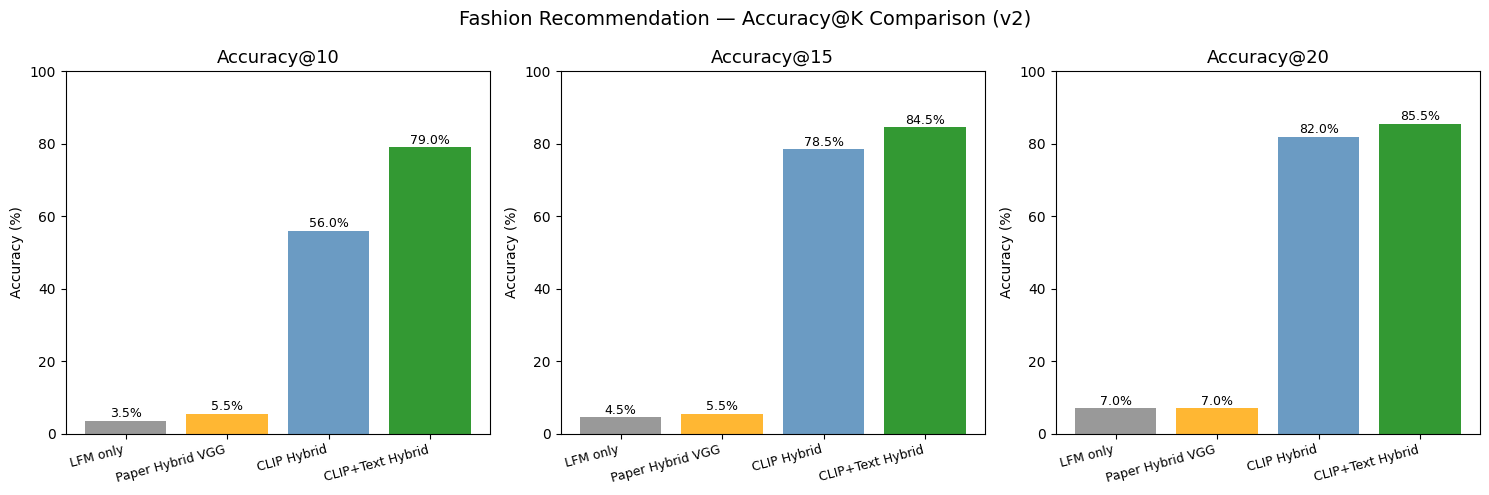

✅ Biểu đồ lưu → output/accuracy_comparison.png


In [30]:
# Vẽ biểu đồ so sánh Accuracy@K
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ks = [10, 15, 20]
methods_plot = {
    'LFM only (v2)'         : 'gray',
    'Paper Hybrid VGG (v2)' : 'orange',
    'CLIP Hybrid (v2)'      : 'steelblue',
    'CLIP+Text Hybrid (v2)' : 'green',
}

for ax, k in zip(axes, ks):
    names = list(methods_plot.keys())
    accs  = [full_results[n][k]['Acc']*100 for n in names]
    bars  = ax.bar(range(len(names)), accs,
                   color=list(methods_plot.values()), alpha=0.8)
    ax.set_title(f'Accuracy@{k}', fontsize=13)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace(' (v2)','') for n in names],
                       rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Accuracy (%)')
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1, f'{acc:.1f}%',
                ha='center', fontsize=9)

plt.suptitle('Fashion Recommendation — Accuracy@K Comparison (v2)', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/output/accuracy_comparison.png', dpi=150)
plt.show()
print('✅ Biểu đồ lưu → output/accuracy_comparison.png')

In [31]:
# ── Bảng kết quả đẹp ─────────────────────────────────────────────────────────
W = 30

for metric, key in [('PRECISION@K', 'P'), ('RECALL@K', 'R'), ('ACCURACY@K (Hit Rate)', 'Acc')]:
    print('\n' + '='*75)
    print(metric)
    print('='*75)
    print(f"{'Method':<{W}} {'k=10':>12} {'k=15':>12} {'k=20':>12}")
    print('-'*75)

    prev_group = None
    for name in all_methods:
        group = 'v2' if '(v2)' in name else 'v1'
        if prev_group and group != prev_group:
            print()  # dòng trống phân cách v1/v2
        prev_group = group

        vals = [full_results[name][k][key]*100 for k in [10, 15, 20]]
        print(f"{name:<{W}} {vals[0]:>11.1f}% {vals[1]:>11.1f}% {vals[2]:>11.1f}%")

# Lưu CSV
rows = []
for name in all_methods:
    for k in [10, 15, 20]:
        rows.append({
            'method': name,
            'k': k,
            'precision': full_results[name][k]['P'],
            'recall':    full_results[name][k]['R'],
            'accuracy':  full_results[name][k]['Acc'],
        })
pd.DataFrame(rows).to_csv('/kaggle/working/output/results_v2.csv', index=False)
print('\n✅ Kết quả lưu → /kaggle/working/output/results_v2.csv')


PRECISION@K
Method                                 k=10         k=15         k=20
---------------------------------------------------------------------------
LFM only (v1)                          1.0%         1.5%         2.0%
Paper Hybrid VGG (v1)                  0.5%         0.0%         2.0%
CLIP Hybrid (v1)                       9.0%        16.5%        33.0%
CLIP+Text Hybrid (v1)                 70.5%        78.5%        84.0%

LFM only (v2)                          3.5%         4.5%         7.0%
Paper Hybrid VGG (v2)                  5.5%         5.5%         7.0%
CLIP Hybrid (v2)                      56.0%        78.5%        82.0%
CLIP+Text Hybrid (v2)                 79.0%        84.5%        85.5%

RECALL@K
Method                                 k=10         k=15         k=20
---------------------------------------------------------------------------
LFM only (v1)                          0.1%         0.1%         0.1%
Paper Hybrid VGG (v1)                  0.1%         0.

In [32]:
# ── Verify lại VGG-DAE sau retrain ───────────────────────────────────────────
print('=== Verify VGG-DAE sau retrain ===')

dae.eval()
pred_sims_new = []

for _, row in tqdm(test_df_v2.iterrows(), total=len(test_df_v2), desc='Verify'):
    top, bot, shoe = row['top'], row['bottom'], row['shoe']
    if top not in features_dict or bot not in features_dict or shoe not in features_dict:
        continue
    f_top = features_dict[top]
    f_bot = features_dict[bot]
    f_shoe = features_dict[shoe]
    masked_t = torch.FloatTensor(
        np.concatenate([f_top, f_bot, np.zeros(FEAT_DIM, np.float32)])
    ).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = dae.get_shoe_feature(masked_t, FEAT_DIM).cpu().numpy()
    pred_sims_new.append(cos_sim(pred, f_shoe.reshape(1,-1))[0][0])

print(f'\nCosine sim (predicted vs true shoe) TRƯỚC retrain: {np.mean(pred_cos_sims):.4f}')
print(f'Cosine sim (predicted vs true shoe) SAU retrain:  {np.mean(pred_sims_new):.4f}')
delta = np.mean(pred_sims_new) - np.mean(pred_cos_sims)
sign = '+' if delta >= 0 else ''
print(f'Thay đổi: {sign}{delta:.4f}')
print()
print('=== Tóm tắt nguyên nhân Paper Hybrid (VGG) kém ===')
print(f'1. VGG features 4096-dim rất cao chiều → DAE khó reconstruct')
print(f'   (CLIP chỉ 512-dim, Text 384-dim → dễ học hơn)')
print(f'2. also_bought triplets noisy → LFM học signal yếu hơn v1')
print(f'3. RRF equal weight → VGG rank nhiễu kéo tổng score xuống')
print(f'   → Fix: Weighted RRF (VGG weight thấp hơn) ở v2')

=== Verify VGG-DAE sau retrain ===


Verify: 100%|██████████| 223/223 [00:00<00:00, 443.70it/s]


Cosine sim (predicted vs true shoe) TRƯỚC retrain: 0.3229
Cosine sim (predicted vs true shoe) SAU retrain:  0.3269
Thay đổi: +0.0040

=== Tóm tắt nguyên nhân Paper Hybrid (VGG) kém ===
1. VGG features 4096-dim rất cao chiều → DAE khó reconstruct
   (CLIP chỉ 512-dim, Text 384-dim → dễ học hơn)
2. also_bought triplets noisy → LFM học signal yếu hơn v1
3. RRF equal weight → VGG rank nhiễu kéo tổng score xuống
   → Fix: Weighted RRF (VGG weight thấp hơn) ở v2
